# Phase 1: Data Collection & Preprocessing

**Collects:**
1. Daily crude oil prices (Brent & WTI) from Yahoo Finance
2. News articles from The Guardian API

**Outputs:** `data/oil_prices.csv`, `data/guardian_articles_clean.csv`

In [2]:
import os
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed

try:
    import yfinance as yf
except ImportError:
    !pip install yfinance --quiet
    import yfinance as yf

try:
    import ftfy
except ImportError:
    !pip install ftfy --quiet
    import ftfy

os.makedirs("data", exist_ok=True)
os.makedirs("plots", exist_ok=True)

print("Ready.")

Ready.


In [3]:
# =============================================================================
# CONFIG
# =============================================================================
GUARDIAN_API_KEY = "API-KEY-HERE"

CRISIS_DATE = "2026-03-04"
PRICE_HISTORY_START = "2023-01-01"   # ~3 years training data
NEWS_START = "2024-07-01"            # 20 months pre-crisis for baseline
DATA_END = "2026-04-10"              # adjust to today's date when you run

GUARDIAN_QUERIES = [
    "Strait of Hormuz",
    "Hormuz oil",
    "Iran oil blockade",
    "Iran strait closure",
    "oil tanker Iran",
    "Persian Gulf oil crisis",
    "Hormuz shipping",
    "Iran oil sanctions",
    "oil supply disruption Middle East",
    "OPEC Iran crisis",
    "Iran military Gulf",
    "Iran tensions oil",
    "Gulf shipping insurance",
    "Iran naval exercises",
    "Iran US standoff oil",
    "Middle East oil threat",
]

# Relevance filter — at least one must appear in headline or trail_text
RELEVANCE_TERMS = [
    "oil", "crude", "petroleum", "barrel", "brent", "opec",
    "hormuz", "strait", "tanker", "shipping", "energy",
    "iran", "gulf", "pipeline", "refinery", "fuel",
    "sanctions", "blockade", "naval", "lng", "gas price",
]

---
## 1. Oil Prices (Brent & WTI)

In [4]:
print("Downloading Brent & WTI prices...")

brent = yf.download("BZ=F", start=PRICE_HISTORY_START, end=DATA_END, progress=False)
wti = yf.download("CL=F", start=PRICE_HISTORY_START, end=DATA_END, progress=False)

# Flatten multi-level columns if present
if isinstance(brent.columns, pd.MultiIndex):
    brent.columns = brent.columns.get_level_values(0)
if isinstance(wti.columns, pd.MultiIndex):
    wti.columns = wti.columns.get_level_values(0)

prices = pd.DataFrame({
    "date": brent.index,
    "brent_open": brent["Open"].values,
    "brent_high": brent["High"].values,
    "brent_low": brent["Low"].values,
    "brent_close": brent["Close"].values,
    "brent_volume": brent["Volume"].values,
    "wti_open": wti.reindex(brent.index)["Open"].values,
    "wti_high": wti.reindex(brent.index)["High"].values,
    "wti_low": wti.reindex(brent.index)["Low"].values,
    "wti_close": wti.reindex(brent.index)["Close"].values,
    "wti_volume": wti.reindex(brent.index)["Volume"].values,
})

prices["date"] = pd.to_datetime(prices["date"]).dt.date
prices = prices.dropna(subset=["brent_close"])

# Derived features
prices["brent_daily_return"] = prices["brent_close"].pct_change()
prices["wti_daily_return"] = prices["wti_close"].pct_change()
prices["brent_volatility_5d"] = prices["brent_daily_return"].rolling(5).std()
prices["brent_ma_20"] = prices["brent_close"].rolling(20).mean()
prices["brent_ma_50"] = prices["brent_close"].rolling(50).mean()
prices["brent_wti_spread"] = prices["brent_close"] - prices["wti_close"]
prices["spread_ma_10"] = prices["brent_wti_spread"].rolling(10).mean()
prices["is_crisis"] = prices["date"] >= pd.to_datetime(CRISIS_DATE).date()

prices.to_csv("data/oil_prices.csv", index=False)

print(f"Saved {len(prices)} rows")
print(f"Date range: {prices['date'].min()} to {prices['date'].max()}")
print(f"Brent close: ${prices['brent_close'].min():.2f} - ${prices['brent_close'].max():.2f}")
print(f"Pre-crisis: {(~prices['is_crisis']).sum()} | Crisis: {prices['is_crisis'].sum()}")
prices.tail()

Saved 822 rows
Date range: 2023-01-03 to 2026-04-09
Brent close: $58.92 - $118.35
Pre-crisis: 796 | Crisis: 26


/var/folders/34/dtpshkp560zf88hmqtgkjg880000gn/T/ipykernel_45312/2835044746.py:31: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  prices["wti_daily_return"] = prices["wti_close"].pct_change()


,date,brent_open,brent_high,brent_low,brent_close,brent_volume,wti_open,wti_high,wti_low,wti_close,wti_volume,brent_daily_return,wti_daily_return,brent_volatility_5d,brent_ma_20,brent_ma_50,brent_wti_spread,spread_ma_10,is_crisis
817,2026-04-02,100.300003,109.709999,99.019997,109.029999,0,98.919998,113.970001,97.500000,111.540001,0.0,0.077797,0.114063,0.088373,103.7715,83.8602,-2.510002,10.158001,True
818,2026-04-06,109.199997,111.870003,106.849998,109.769997,27863,112.959999,115.480003,108.889999,112.410004,271742.0,0.006787,0.007800,0.086053,104.6255,84.7744,-2.640007,8.507000,True
819,2026-04-07,109.589996,111.800003,104.570000,109.269997,65194,112.620003,117.629997,109.199997,112.949997,429331.0,-0.004555,0.004804,0.086031,105.1410,85.6422,-3.680000,6.957999,True
820,2026-04-08,103.400002,104.000000,90.010002,94.750000,82140,108.739998,109.190002,91.050003,94.410004,599576.0,-0.132882,-0.164143,0.096209,105.4885,86.2254,0.339996,5.777999,True
821,2026-04-09,96.529999,99.519997,94.339996,95.919998,82140,96.779999,102.699997,95.250000,97.870003,599576.0,0.012348,0.036649,0.076813,105.6855,86.7924,-1.950005,4.392999,True


---
## 2. Guardian News Articles

In [5]:
def search_guardian(query, from_date, to_date, page=1):
    """Single Guardian API call with proper encoding."""
    url = "https://content.guardianapis.com/search"
    params = {
        "q": query,
        "from-date": from_date,
        "to-date": to_date,
        "page-size": 50,
        "page": page,
        "show-fields": "headline,trailText,bodyText,wordcount",
        "show-tags": "keyword",
        "order-by": "oldest",
        "api-key": GUARDIAN_API_KEY,
    }
    resp = requests.get(url, params=params, timeout=30)
    resp.encoding = "utf-8"  # force UTF-8 decoding
    resp.raise_for_status()
    return resp.json()["response"]


def fix_encoding(text):
    """Fix mojibake from UTF-8 misread as Windows-1252."""
    if not isinstance(text, str):
        return text
    return ftfy.fix_text(text)


def fetch_all_pages_for_query(query):
    """Fetch all pages for a single query. Runs in its own thread."""
    articles = []
    page = 1
    retries = 0
    while True:
        try:
            data = search_guardian(query, NEWS_START, DATA_END, page=page)
        except requests.exceptions.HTTPError as e:
            if e.response is not None and e.response.status_code == 429:
                retries += 1
                if retries > 3:
                    print(f"    [{query[:30]}] Rate limited, stopping at page {page} ({len(articles)} articles)")
                    break
                wait = 2 ** retries  # exponential backoff: 2s, 4s, 8s
                time.sleep(wait)
                continue
            else:
                print(f"    [{query[:30]}] HTTP error: {e}")
                break
        except Exception as e:
            print(f"    [{query[:30]}] Error on page {page}: {e}")
            break

        retries = 0  # reset on success
        results = data.get("results", [])
        if not results:
            break

        for r in results:
            fields = r.get("fields", {})
            tags = r.get("tags", [])
            keywords = [t.get("webTitle", "") for t in tags if t.get("type") == "keyword"]

            articles.append({
                "id": r.get("id", ""),
                "date": r.get("webPublicationDate", "")[:10],
                "section": r.get("sectionName", ""),
                "headline": fix_encoding(fields.get("headline", "")),
                "trail_text": fix_encoding(fields.get("trailText", "")),
                "body_text": fix_encoding(fields.get("bodyText", ""))[:2000],
                "word_count": fields.get("wordcount", ""),
                "url": r.get("webUrl", ""),
                "keywords": "|".join(keywords),
                "search_query": query,
            })

        total_pages = data.get("pages", 1)
        if page >= total_pages:
            break
        page += 1
        time.sleep(1.1)  # Guardian free tier: 1 call/sec

    print(f"    Done: '{query[:40]}' -> {len(articles)} articles")
    return articles

In [6]:
# Run collection — 2 threads to stay safe with 1 call/sec limit
# (each thread waits 1.1s between calls, 2 threads = ~1.8 calls/sec peak)
# If you still get 429s, drop to max_workers=1

print(f"Collecting Guardian articles ({len(GUARDIAN_QUERIES)} queries)...")
print(f"Date range: {NEWS_START} to {DATA_END}")
print(f"This will take a while with the 1 call/sec rate limit.\n")

all_articles = []

with ThreadPoolExecutor(max_workers=2) as executor:
    futures = {
        executor.submit(fetch_all_pages_for_query, q): q
        for q in GUARDIAN_QUERIES
    }
    for future in as_completed(futures):
        try:
            articles = future.result()
            all_articles.extend(articles)
        except Exception as e:
            print(f"    Thread error for '{futures[future]}': {e}")

# Deduplicate
seen_ids = set()
unique = []
for a in all_articles:
    if a["id"] not in seen_ids:
        seen_ids.add(a["id"])
        unique.append(a)

df_raw = pd.DataFrame(unique)
print(f"\nTotal fetched: {len(all_articles)} -> {len(df_raw)} unique")

# Save raw just in case
df_raw.to_csv("data/guardian_articles_raw.csv", index=False)
print(f"Saved raw to data/guardian_articles_raw.csv")

Date range: 2024-07-01 to 2026-04-10
This will take a while with the 1 call/sec rate limit.

    [Hormuz oil] Rate limited, stopping at page 2 (50 articles)
    Done: 'Hormuz oil' -> 50 articles
    [Strait of Hormuz] Rate limited, stopping at page 4 (150 articles)
    Done: 'Strait of Hormuz' -> 150 articles
    [Iran oil blockade] Rate limited, stopping at page 1 (0 articles)
    Done: 'Iran oil blockade' -> 0 articles
    [Iran strait closure] Rate limited, stopping at page 1 (0 articles)
    Done: 'Iran strait closure' -> 0 articles
    [oil tanker Iran] Rate limited, stopping at page 1 (0 articles)
    Done: 'oil tanker Iran' -> 0 articles
    [Persian Gulf oil crisis] Rate limited, stopping at page 1 (0 articles)
    Done: 'Persian Gulf oil crisis' -> 0 articles
    [Hormuz shipping] Rate limited, stopping at page 1 (0 articles)
    Done: 'Hormuz shipping' -> 0 articles
    [Iran oil sanctions] Rate limited, stopping at page 1 (0 articles)
    Done: 'Iran oil sanctions' -> 0 arti

### 2b. Clean & Filter Articles

In [7]:
# If you already ran collection and just want to reload:
df_raw = pd.read_csv("data/guardian_articles.csv")

print(f"Before filtering: {len(df_raw)} articles")

# Relevance filter
def is_relevant(row):
    text = (
        str(row.get("headline", "")).lower()
        + " "
        + str(row.get("trail_text", "")).lower()
    )
    return any(term in text for term in RELEVANCE_TERMS)

df_raw["relevant"] = df_raw.apply(is_relevant, axis=1)
df_clean = df_raw[df_raw["relevant"]].drop(columns=["relevant"]).copy()

# Parse dates and flag crisis
df_clean["date"] = pd.to_datetime(df_clean["date"]).dt.date
df_clean["is_crisis"] = df_clean["date"] >= pd.to_datetime(CRISIS_DATE).date()
df_clean = df_clean.sort_values("date").reset_index(drop=True)

# Combined text field for sentiment models
df_clean["text_for_sentiment"] = (
    df_clean["headline"].fillna("")
    + ". "
    + df_clean["trail_text"].fillna("")
)

df_clean.to_csv("data/guardian_articles_clean.csv", index=False)

print(f"After filtering: {len(df_clean)} articles")
print(f"Pre-crisis: {(~df_clean['is_crisis']).sum()} | Crisis: {df_clean['is_crisis'].sum()}")
print(f"\nSample headlines:")
for h in df_clean["headline"].sample(5, random_state=42).values:
    print(f"  • {h}")

Before filtering: 8260 articles
After filtering: 2249 articles
Pre-crisis: 1496 | Crisis: 753

Sample headlines:
  • Starmer says talks with Gulf leaders have reinforced sense Iran war ceasefire is ‘fragile’ – as it happened 
  • Iran-Israel’s shadow war is out in the open and will only escalate unless causes are addressed
  • Prolonged high oil prices could ‘crimp’ AI boom, WTO warns
  • Starmer and Reeves need to find ‘escape route’ from winter fuel payments row, says Ed Balls – as it happened
  • Middle East war creating ‘largest supply disruption in the history of oil markets’, as Brent crude hits $100 again – as it happened


In [8]:
# Encoding check — make sure ftfy fixed the mojibake
bad_patterns = ["\u00e2\u0080\u0099", "\u00e2\u0080\u009c", "\u00e2\u0080\u009d",
                "\u201a\u00c4\u00f2", "\u201a\u00c4\u00f4", "\u201a\u00c4\u00ec",
                "\u201a\u00c4\u00f6", "\u00e2\u20ac\u2122"]

mojibake_count = 0
for col in ["headline", "trail_text"]:
    for pattern in bad_patterns:
        mojibake_count += df_clean[col].fillna("").str.contains(pattern, regex=False).sum()

# Also check for the literal garbled strings you saw
garbled = df_clean["headline"].fillna("").str.contains("\u00c4\u00f2|\u00c4\u00f4|\u00c4\u00ec", regex=True).sum()
mojibake_count += garbled

if mojibake_count == 0:
    print("Encoding check PASSED — no mojibake detected")
else:
    print(f"WARNING: {mojibake_count} articles still have encoding issues")
    # Show examples
    mask = df_clean["headline"].fillna("").str.contains("\u00c4", regex=False)
    if mask.any():
        print("Examples:")
        for h in df_clean.loc[mask, "headline"].head(3):
            print(f"  {h}")

Encoding check PASSED — no mojibake detected


### 2c. Article Distribution

In [9]:
df_clean["date_dt"] = pd.to_datetime(df_clean["date"])

weekly = df_clean.groupby(pd.Grouper(key="date_dt", freq="W")).size()

# Just show 2026
weekly_2026 = weekly[weekly.index >= "2026-01-01"]
print("Weekly article counts (2026):")
print(weekly_2026.to_string())
print(f"\nTotal 2026 articles: {weekly_2026.sum()}")

Weekly article counts (2026):
date_dt
2026-01-04     11
2026-01-11     33
2026-01-18     11
2026-01-25      9
2026-02-01     13
2026-02-08     11
2026-02-15     12
2026-02-22      8
2026-03-01     27
2026-03-08    104
2026-03-15    147
2026-03-22    163
2026-03-29    121
2026-04-05    125
2026-04-12    136
Freq: W-SUN

Total 2026 articles: 931


---
## 3. EDA Plots

In [11]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
crisis = pd.to_datetime(CRISIS_DATE)

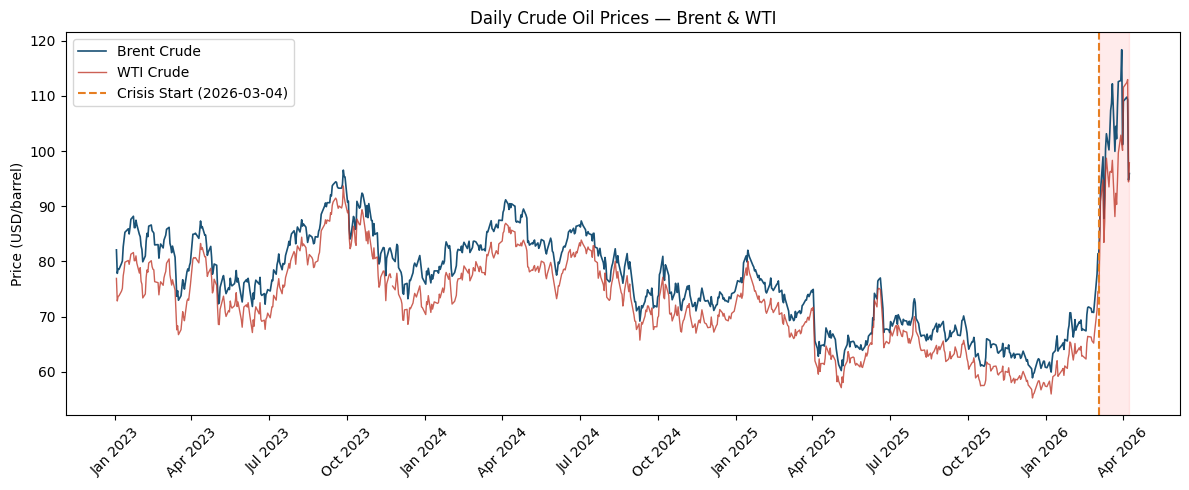

In [17]:
# Price history
fig, ax = plt.subplots(figsize=(12, 5))
dates = pd.to_datetime(prices["date"])
ax.plot(dates, prices["brent_close"], label="Brent Crude", color="#1a5276", linewidth=1.2)
ax.plot(dates, prices["wti_close"], label="WTI Crude", color="#c0392b", linewidth=1.0, alpha=0.8)
ax.axvline(crisis, color="#e67e22", linestyle="--", linewidth=1.5, label=f"Crisis Start ({CRISIS_DATE})")
ax.axvspan(crisis, dates.max(), alpha=0.08, color="red")
ax.set_title("Daily Crude Oil Prices \u2014 Brent & WTI")
ax.set_ylabel("Price (USD/barrel)")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plots/eda_price_history.png", dpi=150)
plt.show()

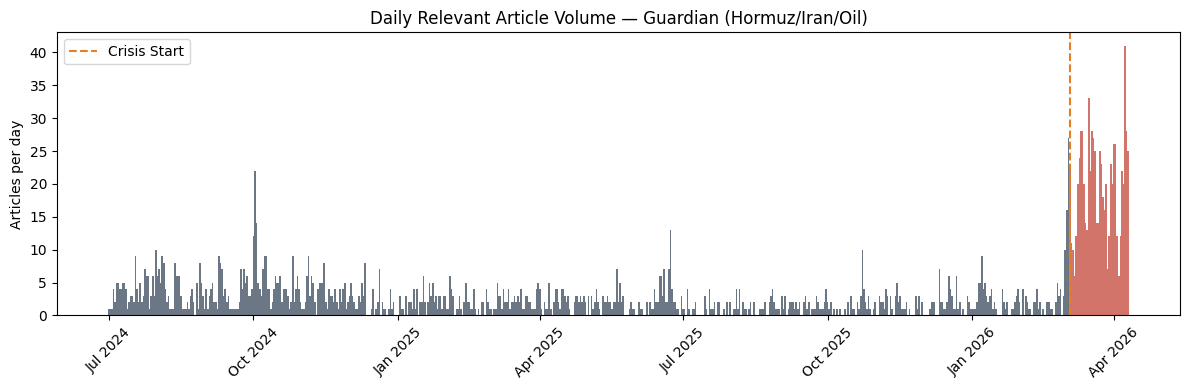

In [18]:
# Article volume with crisis line
fig, ax = plt.subplots(figsize=(12, 4))
daily = df_clean.groupby("date_dt").size().reset_index(name="count")

# Color bars by pre/post crisis
colors = ["#c0392b" if d >= crisis else "#2c3e50" for d in daily["date_dt"]]
ax.bar(daily["date_dt"], daily["count"], color=colors, alpha=0.7, width=1.0)
ax.axvline(crisis, color="#e67e22", linestyle="--", linewidth=1.5, label="Crisis Start")
ax.set_title("Daily Relevant Article Volume \u2014 Guardian (Hormuz/Iran/Oil)")
ax.set_ylabel("Articles per day")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plots/eda_article_volume.png", dpi=150)
plt.show()

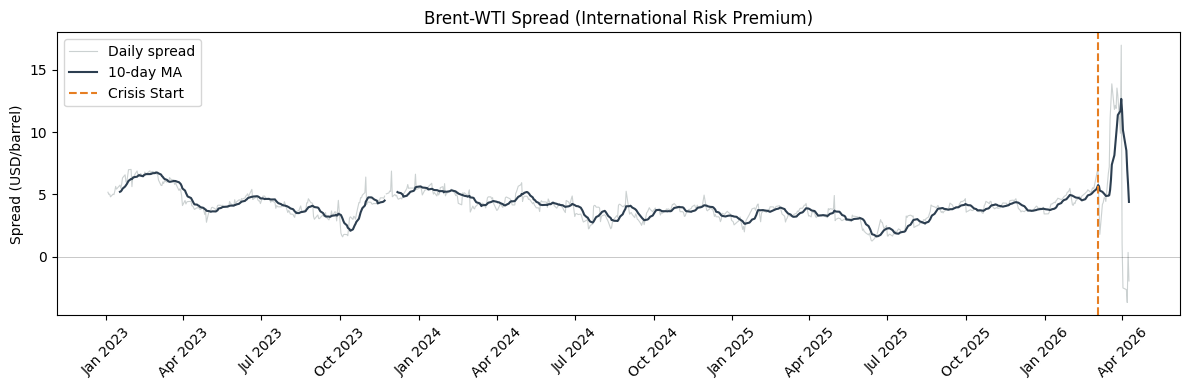

In [20]:
# Brent-WTI spread (early warning signal)
fig, ax = plt.subplots(figsize=(12, 4))
dates = pd.to_datetime(prices["date"])
ax.plot(dates, prices["brent_wti_spread"], color="#7f8c8d", alpha=0.4, linewidth=0.8, label="Daily spread")
ax.plot(dates, prices["spread_ma_10"], color="#2c3e50", linewidth=1.5, label="10-day MA")
ax.axvline(crisis, color="#e67e22", linestyle="--", linewidth=1.5, label="Crisis Start")
ax.axhline(0, color="black", linewidth=0.5, alpha=0.3)
ax.set_title("Brent-WTI Spread (International Risk Premium)")
ax.set_ylabel("Spread (USD/barrel)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plots/eda_spread.png", dpi=150)
plt.show()